# Project Environment Setup

In [ ]:
%pip install -q kagglehub

from pathlib import Path
import os
import shutil
import kagglehub

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / "aeroscan_dataset"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

DATA_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def is_valid_dataset(path):
    path = Path(path)
    required = ["train", "val", "test"]
    return all((path / folder).is_dir() for folder in required)

if not is_valid_dataset(DATA_DIR):
    print("Dataset missing or incomplete. Downloading from Kaggle...")

    if DATA_DIR.exists():
        shutil.rmtree(DATA_DIR)

    downloaded_path = Path(
        kagglehub.dataset_download(
            "ahnuf05/aeroscan-military-aircraft-classification"
        )
    )

    print("Downloaded to:", downloaded_path)
    shutil.copytree(downloaded_path, DATA_DIR, dirs_exist_ok=True)

print("\nVerifying dataset structure...")

if not is_valid_dataset(DATA_DIR):
    raise RuntimeError(
        "Dataset is incomplete. Confirm that the downloaded dataset "
        "contains train, val, and test folders."
    )

print("Dataset is complete.")
print("Found folders:", sorted(path.name for path in DATA_DIR.iterdir()))

data_dir = str(DATA_DIR)
print("\nDataset ready at:", DATA_DIR.resolve())
print("Checkpoints will be saved at:", CHECKPOINT_DIR.resolve())

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize

from sklearn import metrics
from tqdm.auto import tqdm
from tqdm.auto import trange

import warnings
warnings.filterwarnings('ignore')

import os
from PIL import Image
import glob
from torchvision import transforms

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Data Processing and Transforms

In [ ]:
# Constants
BACKGROUND_CLASS_ID = 88  # valid classes are 0–87
NUM_CLASSES = 89

In [ ]:
# Custom Torch Dataset
# Defined for Military Aircraft Classification Dataset
class AircraftDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.root_dir = os.path.join(root_dir, split)
        self.transform = transform

        self.image_paths = sorted(glob.glob(os.path.join(self.root_dir, "*.jpg")))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_path = img_path.replace(".jpg", ".txt")

        if not os.path.exists(label_path):
            label = 88
        else:
            with open(label_path, "r") as f:
                lines = f.readlines()

            if len(lines) == 0:
                label = 88
            else:
                label = int(lines[0].split()[0])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # geometric variation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),

    # lighting / color variation
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    # slight zoom/crop
    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_dataset = AircraftDataset(data_dir, "train", transform)
val_dataset   = AircraftDataset(data_dir, "val", val_transform)
test_dataset  = AircraftDataset(data_dir, "test", val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))
print("Total classes:", 89)

Train: 20717
Val: 2564
Test: 2568
Total classes: 89


In [ ]:
train_dir = os.path.join(data_dir, "train")
image_paths = glob.glob(os.path.join(train_dir, "*.jpg"))

class_counts = {i: 0 for i in range(89)}
images_by_class = {}

for img_path in image_paths:
    label_path = img_path.replace(".jpg", ".txt")

    if not os.path.exists(label_path):
        label = 88
    else:
        with open(label_path, "r") as f:
            lines = f.readlines()

        if len(lines) == 0:
            label = 88
        else:
            label = int(lines[0].split()[0])

    class_counts[label] += 1

    if label not in images_by_class:
        images_by_class[label] = img_path

In [ ]:
class_names = [
'A10', 'A400M', 'AG600', 'AH64', 'AKINCI', 'AV8B', 'An124', 'An22', 'An225', 'An72',
'B1', 'B2', 'B52', 'Be200', 'C1', 'C130', 'C17', 'C2', 'C390', 'C5', 'CH47', 'CH53',
'CL415', 'E2', 'E7', 'EF2000', 'EMB314', 'F117', 'F14', 'F15', 'F16', 'F18', 'F2',
'F22', 'F35', 'F4', 'FCK1', 'H6', 'Il76', 'J10', 'J20', 'J35', 'J36', 'JAS39',
'JF17', 'JH7', 'KAAN', 'KC135', 'KF21', 'KJ600', 'Ka27', 'Ka52', 'MQ9', 'Mi24',
'Mi26', 'Mi28', 'Mi8', 'Mig29', 'Mig31', 'Mirage2000', 'P3', 'RQ4', 'Rafale',
'SR71', 'Su24', 'Su25', 'Su34', 'Su47', 'Su57', 'TB001', 'TB2', 'Tejas', 'Tornado',
'Tu160', 'Tu22M', 'Tu95', 'U2', 'UH60', 'US2', 'V22', 'Vulcan', 'WZ7', 'X32',
'XB70', 'Y20', 'YF23', 'Z10', 'Z19', 'BACKGROUND'
]

df = pd.DataFrame({
    "Class_ID": list(range(89)),
    "Class_Name": class_names,
    "Count": [class_counts[i] for i in range(89)]
})

df.sort_values("Count", ascending=False)

,Class_ID,Class_Name,Count
88,88,BACKGROUND,1883
1,1,A400M,240
19,19,C5,240
22,22,CL415,240
15,15,C130,240
...,...,...,...
82,82,X32,200
84,84,Y20,200
85,85,YF23,200
86,86,Z10,200


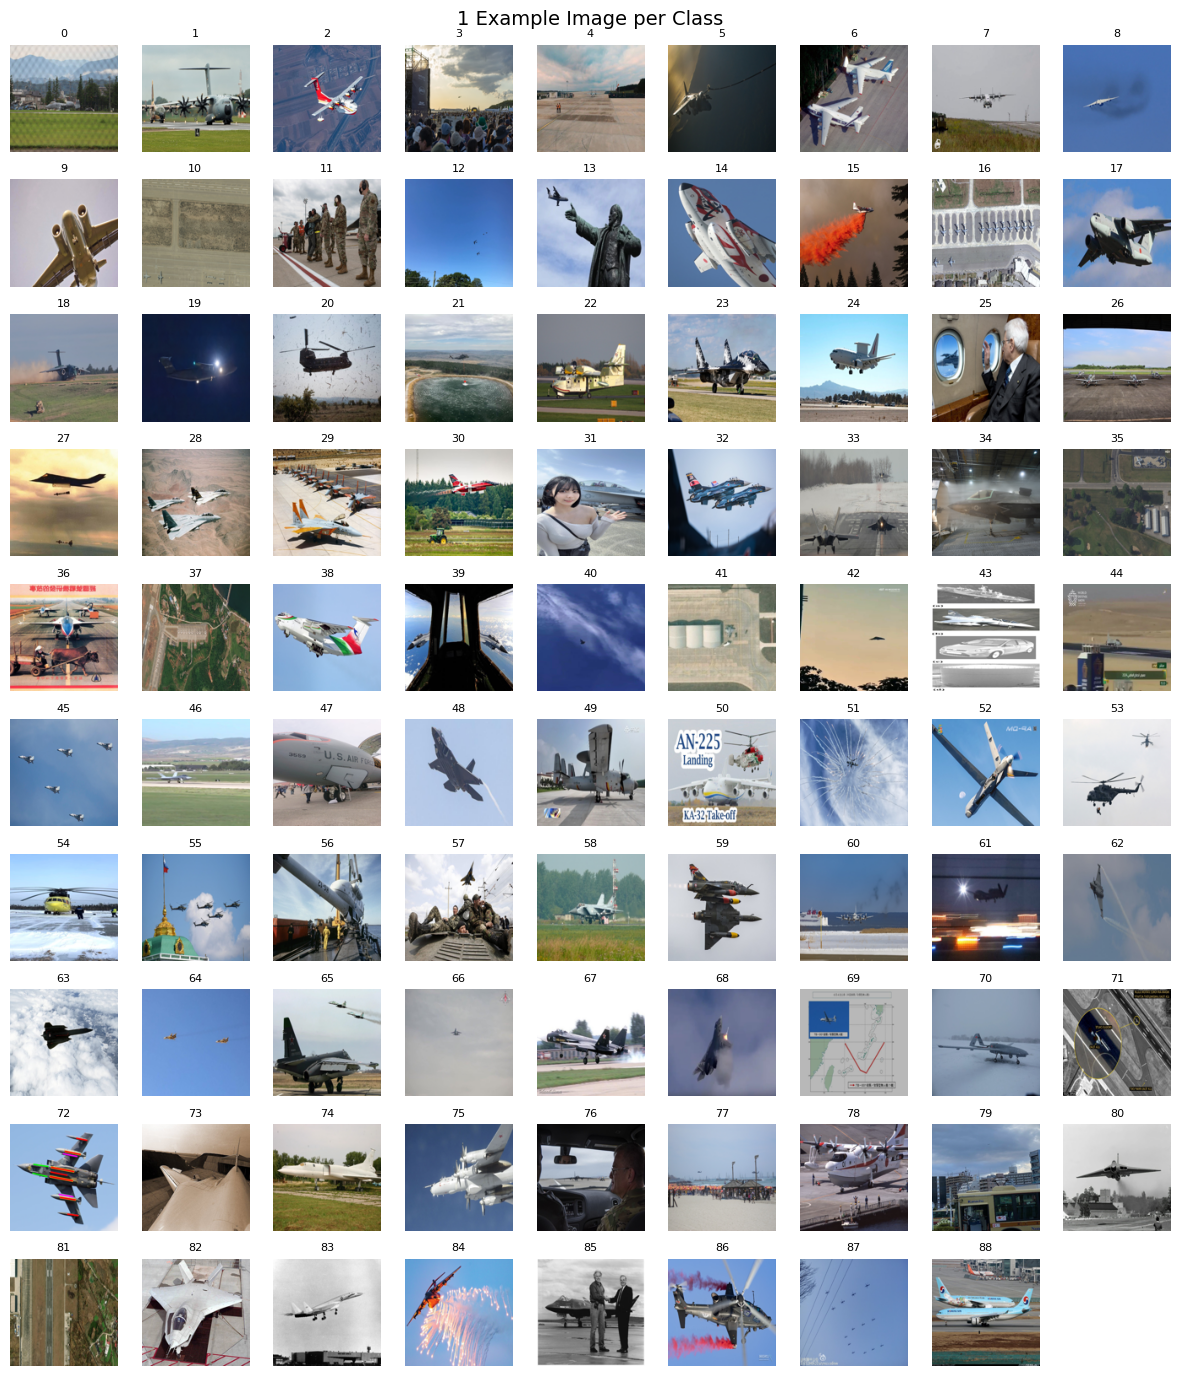

In [ ]:
sorted_classes = sorted(images_by_class.keys())

cols = 9
rows = 10

fig, axs = plt.subplots(rows, cols, figsize=(12, 14))

for idx, cls in enumerate(sorted_classes):
    r = idx // cols
    c = idx % cols

    img = Image.open(images_by_class[cls]).convert("RGB")
    img = img.resize((128, 128))

    axs[r, c].imshow(img)
    axs[r, c].axis("off")
    axs[r, c].set_title(str(cls), fontsize=8)

for j in range(len(sorted_classes), rows * cols):
    r = j // cols
    c = j % cols
    axs[r, c].axis("off")

plt.suptitle("1 Example Image per Class", fontsize=14)
plt.tight_layout()
plt.show()

# Model Training

### Simple CNN

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=89):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
base_path = CHECKPOINT_DIR

checkpoint_path = base_path / "simple_cnn_checkpoint.pth"
best_model_path = base_path / "simple_cnn_best.pth"

start_epoch = 0
best_val_acc = 0.0
history = None

In [ ]:
device = torch.device("cuda")

model = SimpleCNN(num_classes=89).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()

In [ ]:
def train(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0

    loop = tqdm(loader, leave=True)

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        loop.set_description("Training")
        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader)

In [ ]:
def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader, leave=False)

    with torch.no_grad():
        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device).long()

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

    acc = correct / total
    return total_loss / len(loader), acc

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion,
                start_epoch, epochs, device,
                best_val_acc, history, checkpoint_path):

    for epoch in range(start_epoch, start_epoch + epochs):

        train_loss = train(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        # update best accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc

            torch.save(model.state_dict(), best_model_path)

            print(f"New best model saved to Drive (val acc = {val_acc:.4f})")

        # save EVERYTHING in one file
        checkpoint = {
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "best_val_acc": best_val_acc,
            "history": history
        }

        torch.save(checkpoint, checkpoint_path)

    return history, best_val_acc

In [ ]:
# Calls the train loop and saves progress to the local checkpoints directory.
# Can be called again to resume training.
# Can schedule epochs by modifying extra_epochs variable

start_epoch = 0
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": []}

if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]
    history = checkpoint["history"]

    print(f"Resuming from epoch {start_epoch}")
    print(f"Best val acc so far: {best_val_acc:.4f}")

else:
    print("No checkpoint found. Starting fresh.")

extra_epochs = 10

history, best_val_acc = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    start_epoch,
    extra_epochs,
    device,
    best_val_acc,
    history,
    checkpoint_path
)

Loading checkpoint...
Resuming from epoch 50
Best val acc so far: 0.1767


  0%|          | 0/648 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

Epoch [51] | Train Loss: 2.2779 | Val Loss: 4.4349 | Val Acc: 0.1716


  0%|          | 0/648 [00:00<?, ?it/s]

...

  0%|          | 0/81 [00:00<?, ?it/s]

Epoch [59] | Train Loss: 2.1391 | Val Loss: 4.4796 | Val Acc: 0.1732


  0%|          | 0/648 [00:00<?, ?it/s]

  0%|          | 0/81 [00:00<?, ?it/s]

Epoch [60] | Train Loss: 2.1088 | Val Loss: 4.5329 | Val Acc: 0.1712


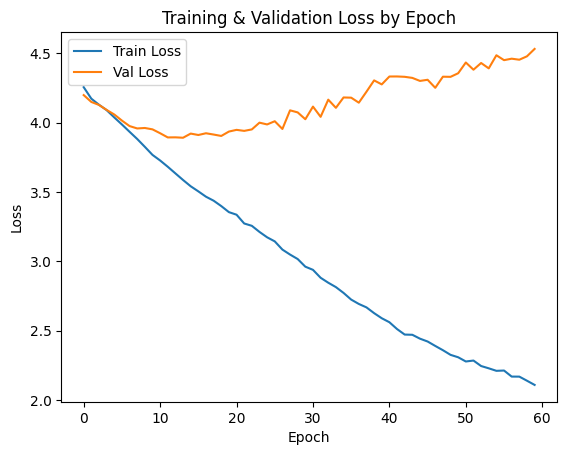

In [ ]:
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss by Epoch")
plt.show()

## ResNet Transfer Learned CNN

Model trained on FC layer first. When validation loss plateaus, unfreeze ResNet layer 4 for fine tuning.

In [ ]:
base_path = CHECKPOINT_DIR

checkpoint_path = base_path / "DEFAULT_WEIGHTS_resnet_152_checkpoint.pth"
best_model_path = base_path / "DEFAULT_WEIGHTS_resnet_152_best.pth" 

In [ ]:
def train(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0

    loop = tqdm(loader, leave=True)

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        loop.set_description("Training")
        loop.set_postfix(loss=loss.item())

    return total_loss / len(loader)

In [ ]:
def validate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    loop = tqdm(loader, leave=False)

    with torch.no_grad():
        for images, labels in loop:
            images = images.to(device)
            labels = labels.to(device).long()

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

    acc = correct / total
    return total_loss / len(loader), acc

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, criterion,
                start_epoch, epochs, device,
                best_val_acc, history, checkpoint_path):

    for epoch in range(start_epoch, start_epoch + epochs):

        train_loss = train(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        # update best accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc

            torch.save(model.state_dict(), best_model_path)

            print(f"New best model saved to Drive (val acc = {val_acc:.4f})")

        # save everything in one file
        checkpoint = {
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "best_val_acc": best_val_acc,
            "history": history
        }

        torch.save(checkpoint, checkpoint_path)

    return history, best_val_acc

Train on FC layer

In [ ]:
import torch
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet
model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace classifier
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 89)

model = model.to(device)

# Optimizer and Loss
optimizer = torch.optim.Adam(
    model.fc.parameters(),   # ONLY train final layer
    lr=3e-4,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()

In [ ]:
start_epoch = 0
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": []}

if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]
    history = checkpoint["history"]

    print(f"Resuming from epoch {start_epoch}")
    print(f"Best val acc so far: {best_val_acc:.4f}")

else:
    print("No checkpoint found. Starting fresh.")

extra_epochs = 5

history, best_val_acc = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    start_epoch,
    extra_epochs,
    device,
    best_val_acc,
    history,
    checkpoint_path
)

In [ ]:
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss by Epoch")
plt.show()

Unfreeze layer 4

In [ ]:
import torch
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained backbone
model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

# Replace classifier FIRST
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 89)

model = model.to(device)

# Load trained weights from phase 1
model.load_state_dict(torch.load(best_model_path, map_location=device))

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer 4
for param in model.layer4.parameters():
    param.requires_grad = True

# Rebuild optimizer
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss()

In [ ]:
# Set new file paths for this phase
checkpoint_path = base_path / "LAYER_4_resnet_152_checkpoint.pth"
best_model_path = base_path / "LAYER_4_resnet_152_best.pth" 

In [ ]:
start_epoch = 0
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": []}

if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]
    history = checkpoint["history"]

    print(f"Resuming from epoch {start_epoch}")
    print(f"Best val acc so far: {best_val_acc:.4f}")

else:
    print("No checkpoint found. Starting fresh.")

extra_epochs = 10

history, best_val_acc = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    start_epoch,
    extra_epochs,
    device,
    best_val_acc,
    history,
    checkpoint_path
)

In [ ]:
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss by Epoch")
plt.show()

Unfreeze layer 3

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained backbone
model = models.resnet152(weights=models.ResNet152_Weights.DEFAULT)

# Replace classifier FIRST
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 89)

model = model.to(device)

# Load trained weights from previous phase
model.load_state_dict(torch.load(best_model_path, map_location=device))

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze layer3 and layer4
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

# Rebuild optimizer (LOWER LR for deeper fine-tuning)
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=3e-5,
    weight_decay=1e-4
)

criterion = nn.CrossEntropyLoss()

In [ ]:
# Set new file paths for this phase
checkpoint_path = base_path / "LAYER_3_resnet_152_checkpoint.pth"
best_model_path = base_path / "LAYER_3_resnet_152_best.pth" 

In [ ]:
start_epoch = 0
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": []}

if os.path.exists(checkpoint_path):
    print("Loading checkpoint...")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])

    start_epoch = checkpoint["epoch"] + 1
    best_val_acc = checkpoint["best_val_acc"]
    history = checkpoint["history"]

    print(f"Resuming from epoch {start_epoch}")
    print(f"Best val acc so far: {best_val_acc:.4f}")

else:
    print("No checkpoint found. Starting fresh.")

extra_epochs = 10

history, best_val_acc = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    start_epoch,
    extra_epochs,
    device,
    best_val_acc,
    history,
    checkpoint_path
)

Graph Generation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = CHECKPOINT_DIR

checkpoint_files = [
    base_path / "DEFAULT_WEIGHTS_resnet_152_checkpoint.pth",
    base_path / "LAYER_4_resnet_152_checkpoint.pth",
    base_path / "LAYER_3_resnet_152_checkpoint.pth"
]

def infer_stage(path):
    name = Path(path).name.upper()

    if "LAYER_4" in name:
        return "LAYER 4"
    elif "LAYER_3" in name:
        return "LAYER 3"
    elif "DEFAULT" in name or "FC" in name:
        return "FC ONLY"
    return "UNKNOWN"


def analyze_checkpoint(path):
    path = Path(path)

    if not path.exists():
        print(f"\nMissing file: {path}")
        return

    ckpt = torch.load(path, map_location=device)
    stage = infer_stage(path)

    print("\n" + "=" * 80)
    print(f"{stage} | {path.name}")
    print("=" * 80)

    history = ckpt.get("history")
    best_val_acc = ckpt.get("best_val_acc")
    last_epoch = ckpt.get("epoch")

    if history is not None and history.get("val_acc"):
        train_losses = history.get("train_loss", [])
        val_losses = history.get("val_loss", [])
        val_accs = history.get("val_acc", [])

        best_epoch = max(range(len(val_accs)), key=lambda i: val_accs[i])

        print("\nBEST PERFORMANCE")
        print(f"Best Epoch: {best_epoch + 1}")
        print(f"Best Val Acc: {val_accs[best_epoch]:.4f}")

        if len(train_losses) > best_epoch:
            print(f"Train Loss @ Best Epoch: {train_losses[best_epoch]:.4f}")
        if len(val_losses) > best_epoch:
            print(f"Val Loss @ Best Epoch: {val_losses[best_epoch]:.4f}")

        print("\nFINAL PERFORMANCE")
        print(f"Final Epoch: {len(val_accs)}")
        print(f"Final Val Acc: {val_accs[-1]:.4f}")

        if train_losses:
            print(f"Final Train Loss: {train_losses[-1]:.4f}")
        if val_losses:
            print(f"Final Val Loss: {val_losses[-1]:.4f}")

        print("\nLOSS EXTREMES")
        print(
            f"Best (min) Train Loss: {min(train_losses):.4f}"
            if train_losses else "No train loss"
        )
        print(
            f"Best (min) Val Loss: {min(val_losses):.4f}"
            if val_losses else "No val loss"
        )
    else:
        print("No full history found.")

        if best_val_acc is not None:
            print(f"Best Val Acc (stored): {best_val_acc:.4f}")
        if last_epoch is not None:
            print(f"Last Epoch: {last_epoch + 1}")

    print("=" * 80)


for file in checkpoint_files:
    analyze_checkpoint(file)